In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import List
from matplotlib.lines import Line2D

def plot_layer_metrics(
    file_path: str,
    project_name: str,
    layers: List[int],
    fisher_options: List[bool],
    module_types: List[str],
    title: str,
    ylabel: str,
    metric: str,
    output_file: str = None
):
    # Load data
    df = pd.read_csv(file_path)
    x = df['Step']

    # Define styles
    colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']
    line_styles = {True: '--', False: '-'}  # Fisher: dashed, No Fisher: solid

    # Set up subplots
    fig, axes = plt.subplots(nrows=len(layers), ncols=1, figsize=(10, 3 * len(layers)), sharex=True)
    if len(layers) == 1:
        axes = [axes]  # Ensure iterable

    for i, layer in enumerate(layers):
        ax = axes[i]
        plotted_labels = set()

        for j, module in enumerate(module_types):
            for fisher in fisher_options:
                fisher_str = str(fisher).lower()
                col_name = f"layer_{layer}_residual_mid_gpt2_{module}_fisher_{fisher_str}_project_{project_name} - {metric}"

                if col_name not in df.columns:
                    print(f"Warning: Missing column '{col_name}'")
                    continue

                y = df[col_name]
                label = module
                plot_label = label if label not in plotted_labels else None
                if plot_label:
                    plotted_labels.add(label)

                ax.plot(
                    x, y,
                    label=plot_label,
                    color=colors[j % len(colors)],
                    linestyle=line_styles[fisher],
                    linewidth=2
                )

        ax.set_ylabel(f"Layer {layer}\n{ylabel}")
        ax.set_yscale('log')
        ax.grid(True, linestyle='--', linewidth=0.5)
        if i == 0:
            ax.set_title(title)
        if i == len(layers) - 1:
            ax.set_xlabel('Training Step')

        # Add custom line style legend (only once)
        if i == 0:
            module_legend = ax.get_legend_handles_labels()
            custom_lines = [
                Line2D([0], [0], color='black', linestyle='-', label='No Fisher'),
                Line2D([0], [0], color='black', linestyle='--', label='Fisher Traced')
            ]
            ax.legend(
                handles=custom_lines + module_legend[0],
                loc='upper right',
                fontsize='small',
                title='Legend'
            )

    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, bbox_inches='tight', format='pdf')
    plt.show()


## Tiny Stories

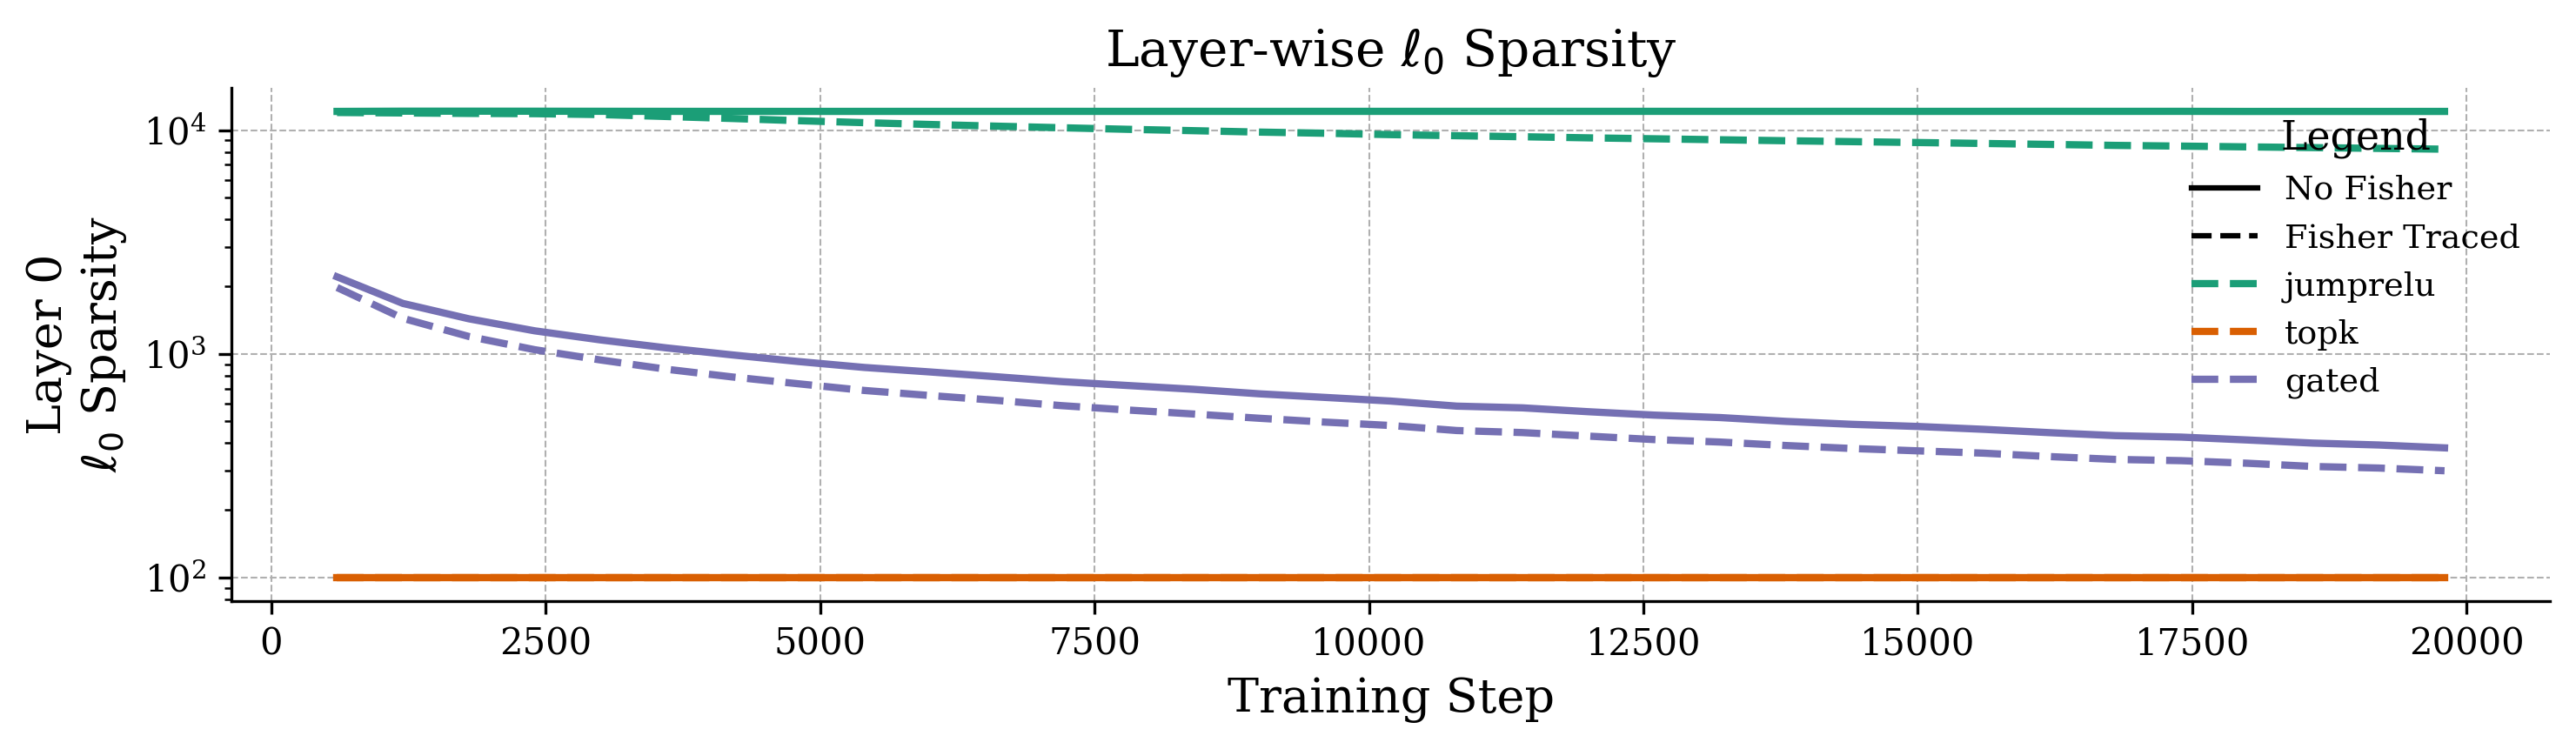

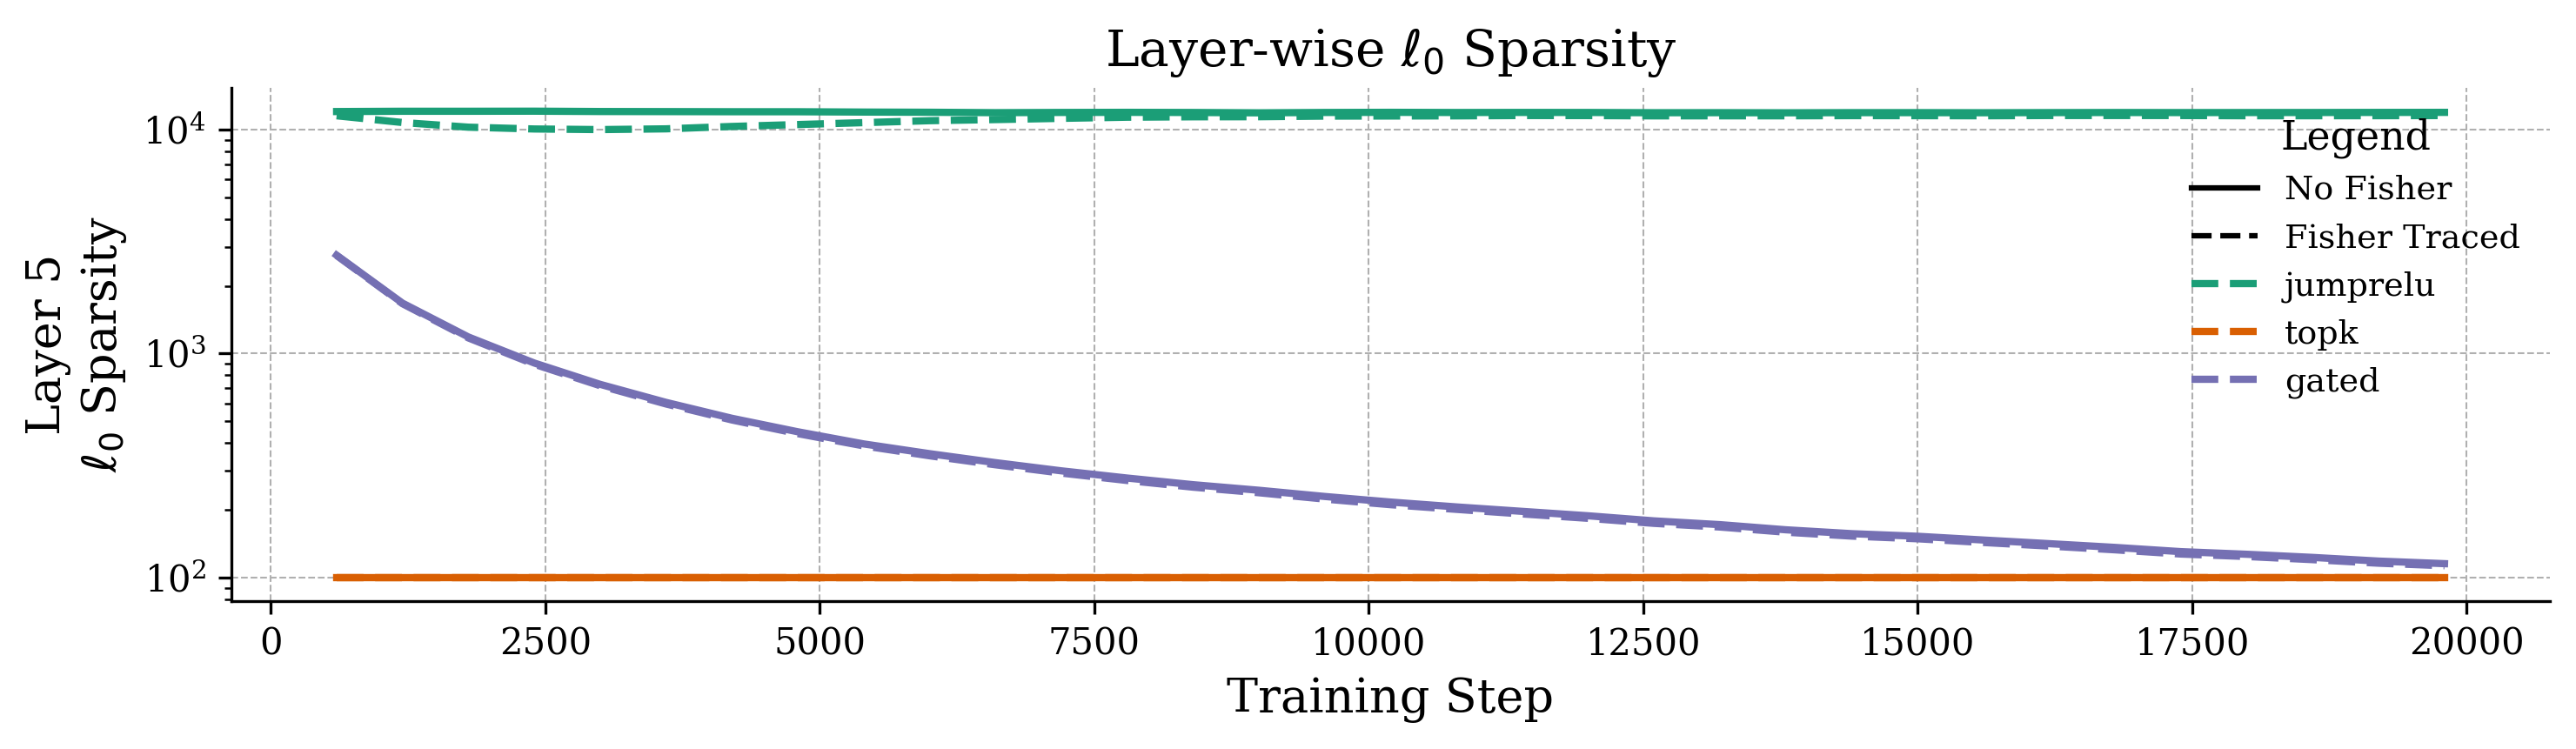

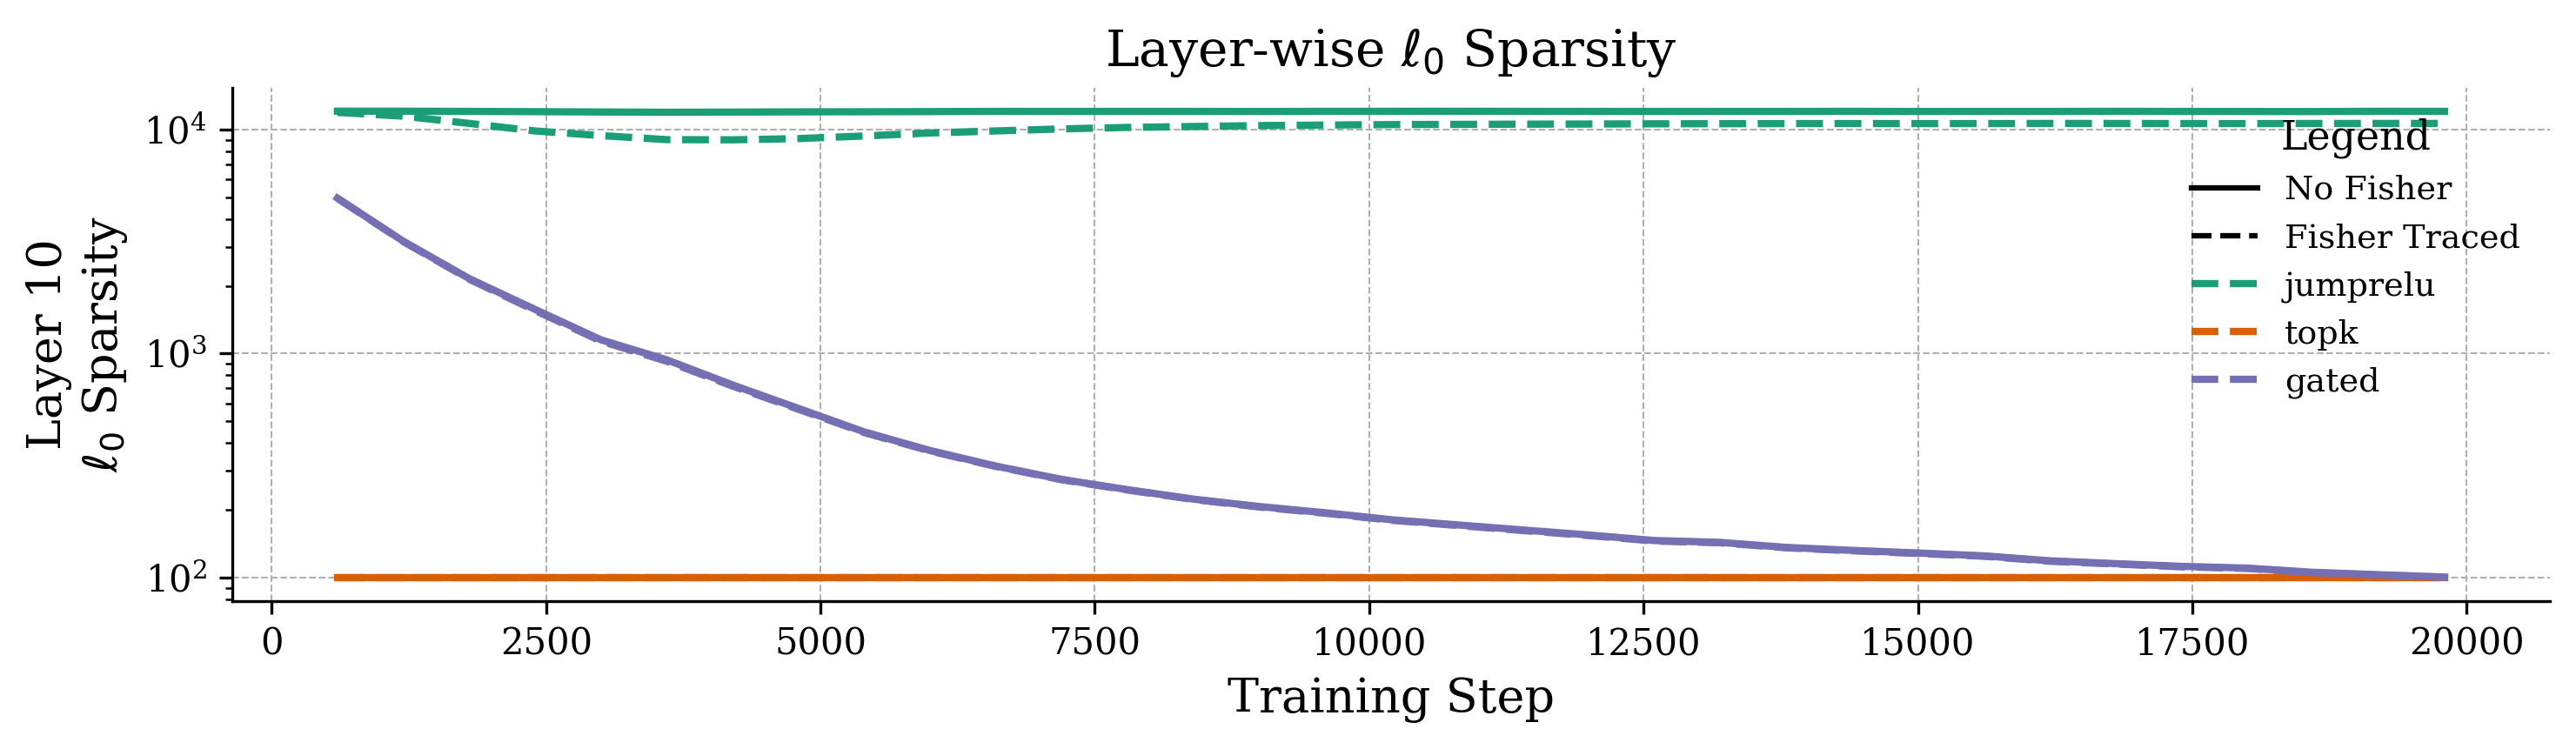

In [68]:
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_0_l0_sparsity.csv',
    layers=[0],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    output_file='TinyStories_residual_mid/layer0_l0_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_5_l0_sparsity.csv',
    layers=[5],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    output_file='TinyStories_residual_mid/layer_5_l0_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_10_l0_sparsity.csv',
    layers=[10],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    output_file='TinyStories_residual_mid/layer_10_l0_sparsity_plot.pdf'
)

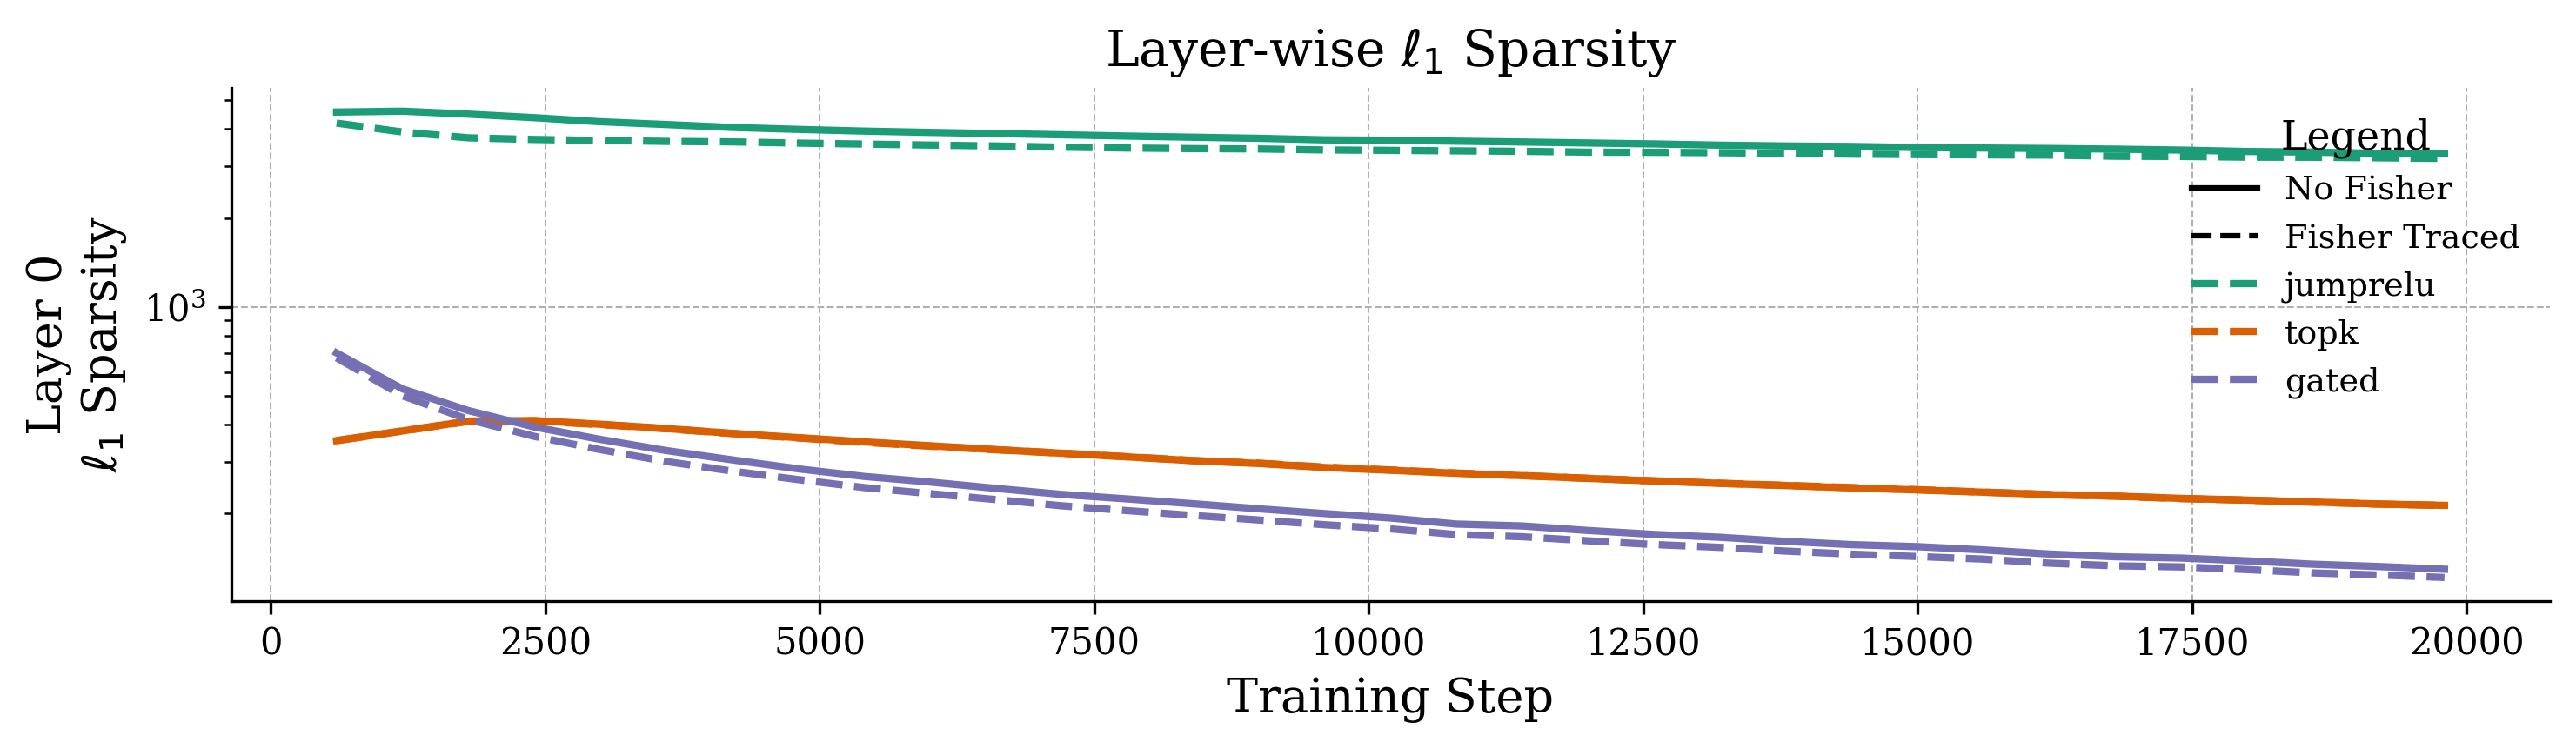

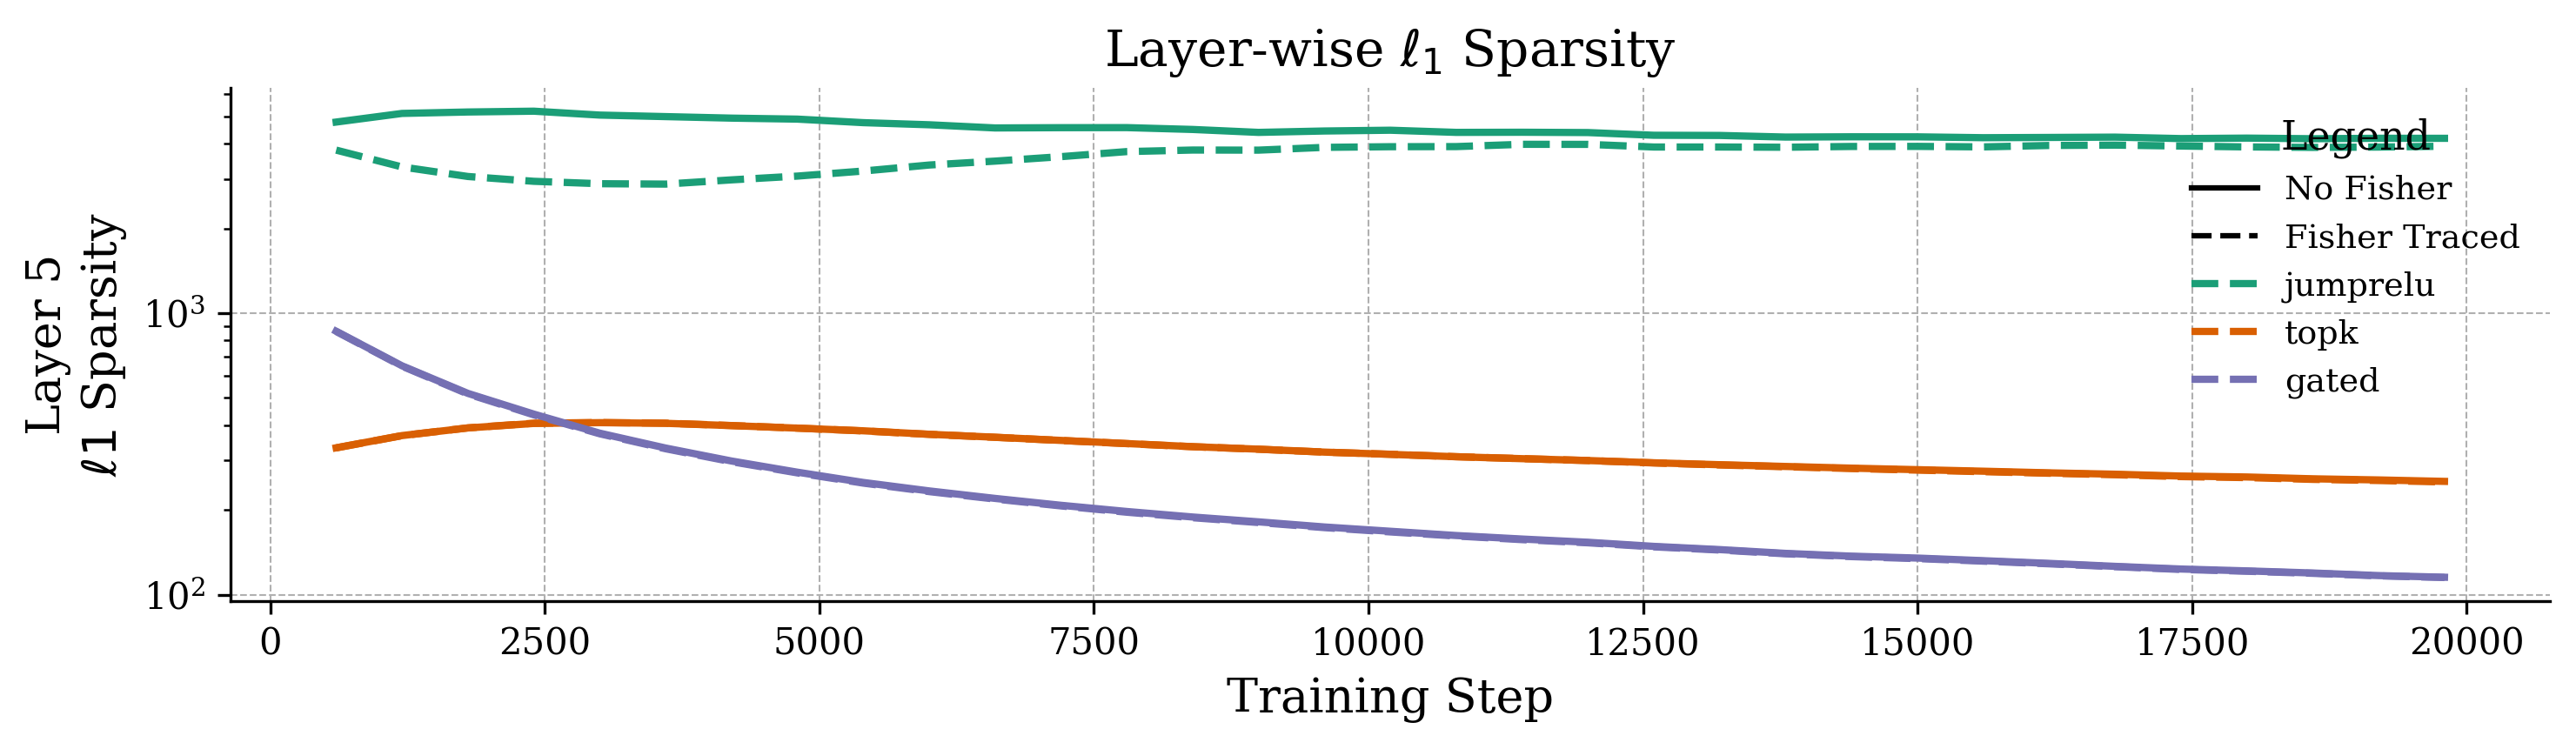

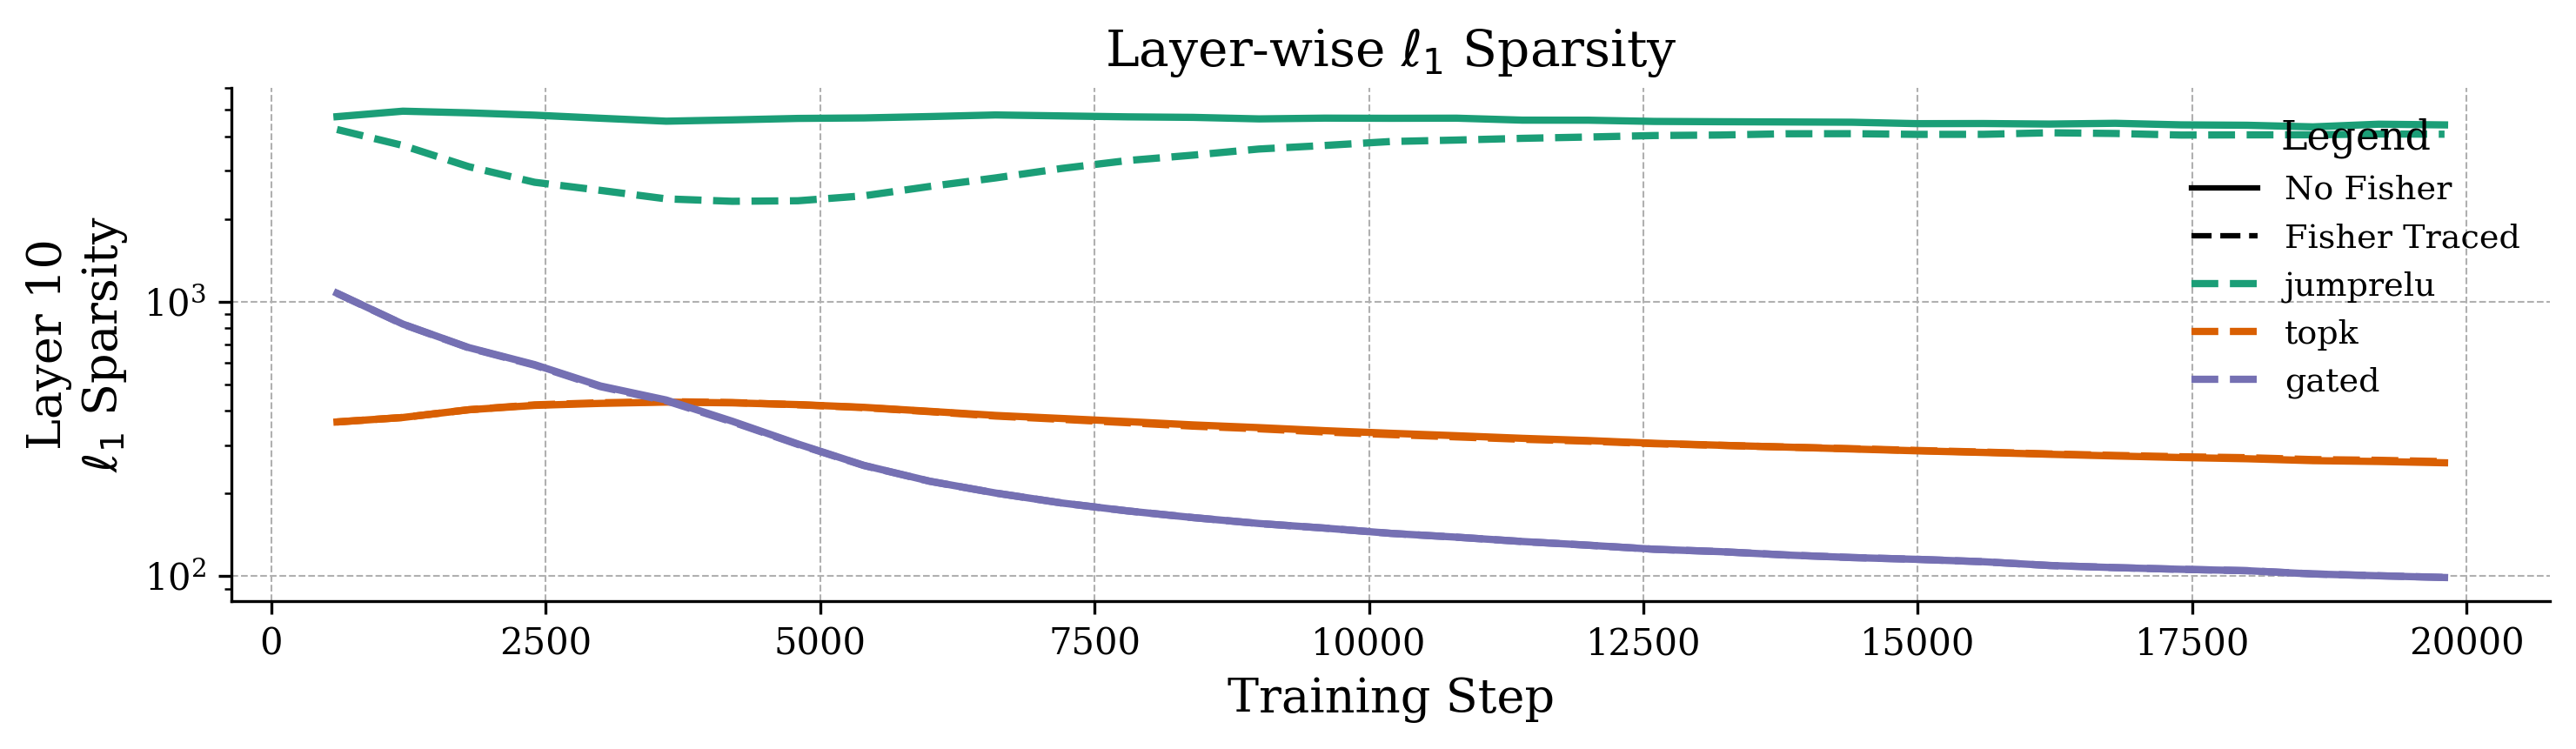

In [69]:
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_0_l1_sparsity.csv',
    layers=[0],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    output_file='TinyStories_residual_mid/layer0_l1_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_5_l1_sparsity.csv',
    layers=[5],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell1$ Sparsity',
    metric='sparsity.l1',
    output_file='TinyStories_residual_mid/layer_5_l1_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_10_l1_sparsity.csv',
    layers=[10],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    output_file='TinyStories_residual_mid/layer_10_l1_sparsity_plot.pdf'
)

## Devign

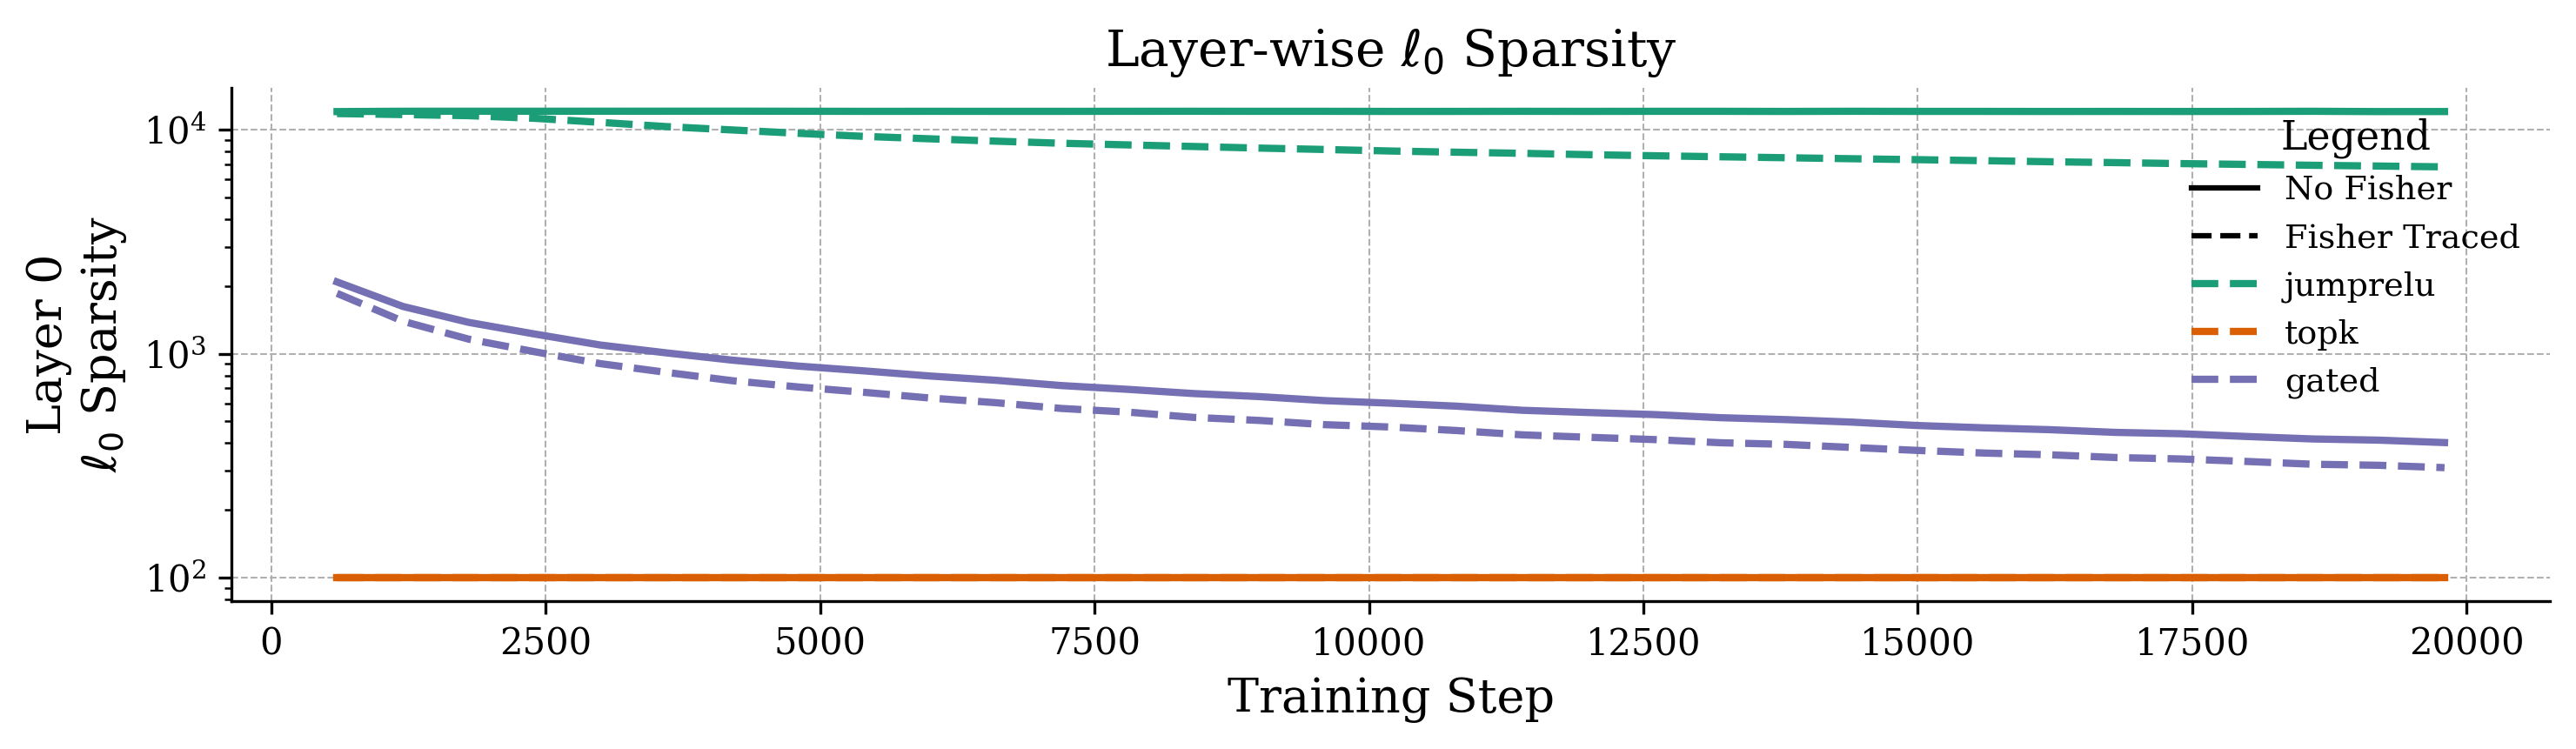

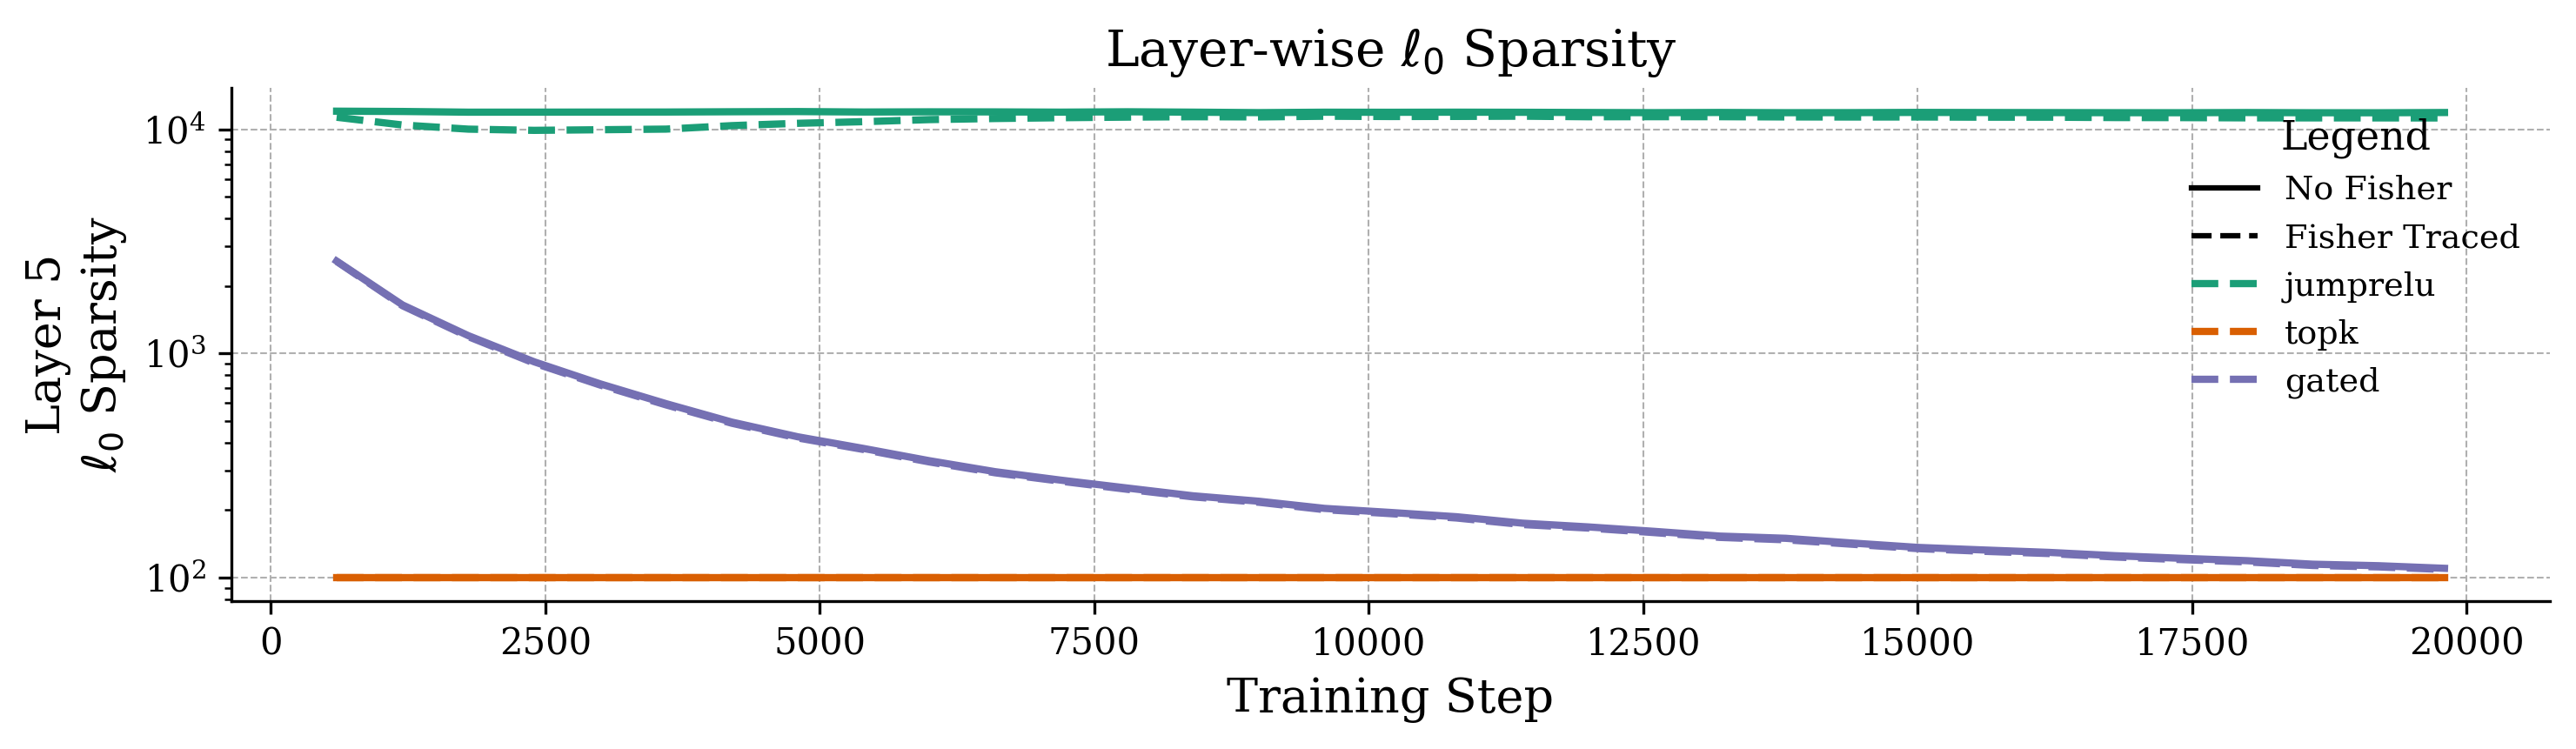

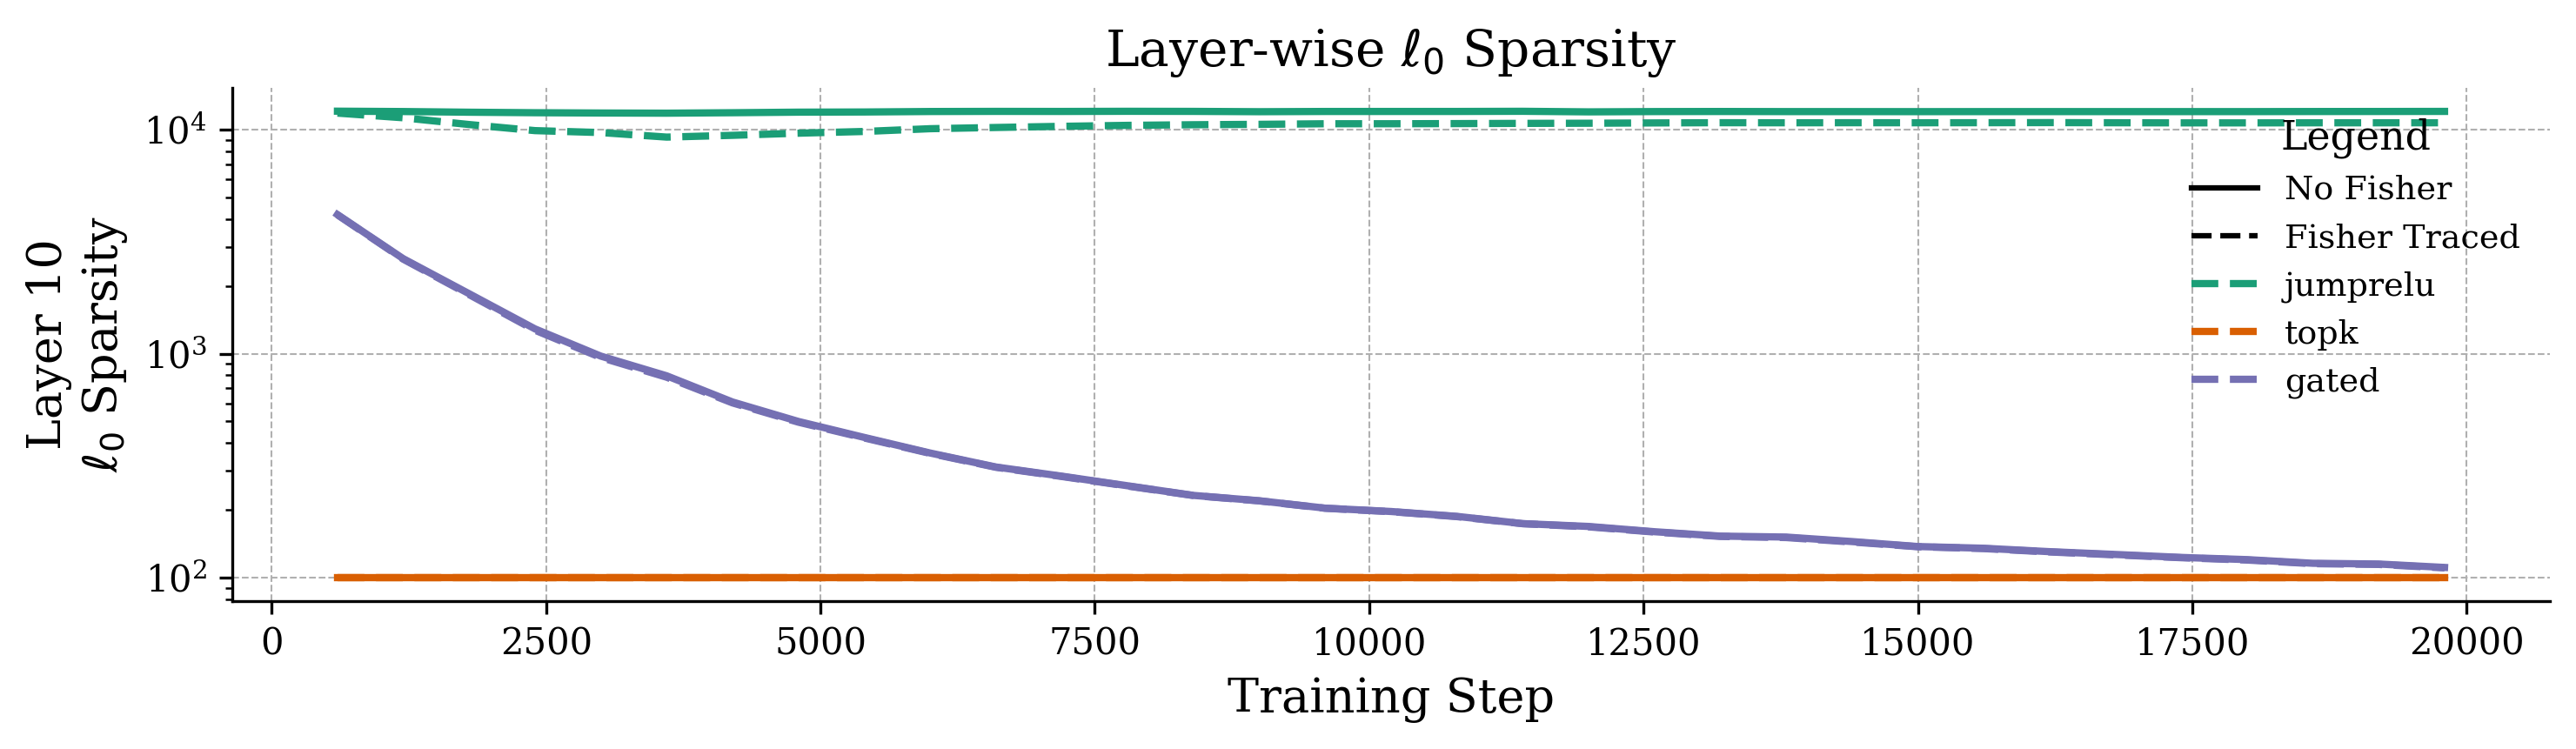

In [70]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_l0_sparsity.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    output_file='Devign_residual_mid/layer0_l0_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_l0_sparsity.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    output_file='Devign_residual_mid/layer5_l0_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_l0_sparsity.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    output_file='Devign_residual_mid/layer10_l0_sparsity_plot.pdf'
)

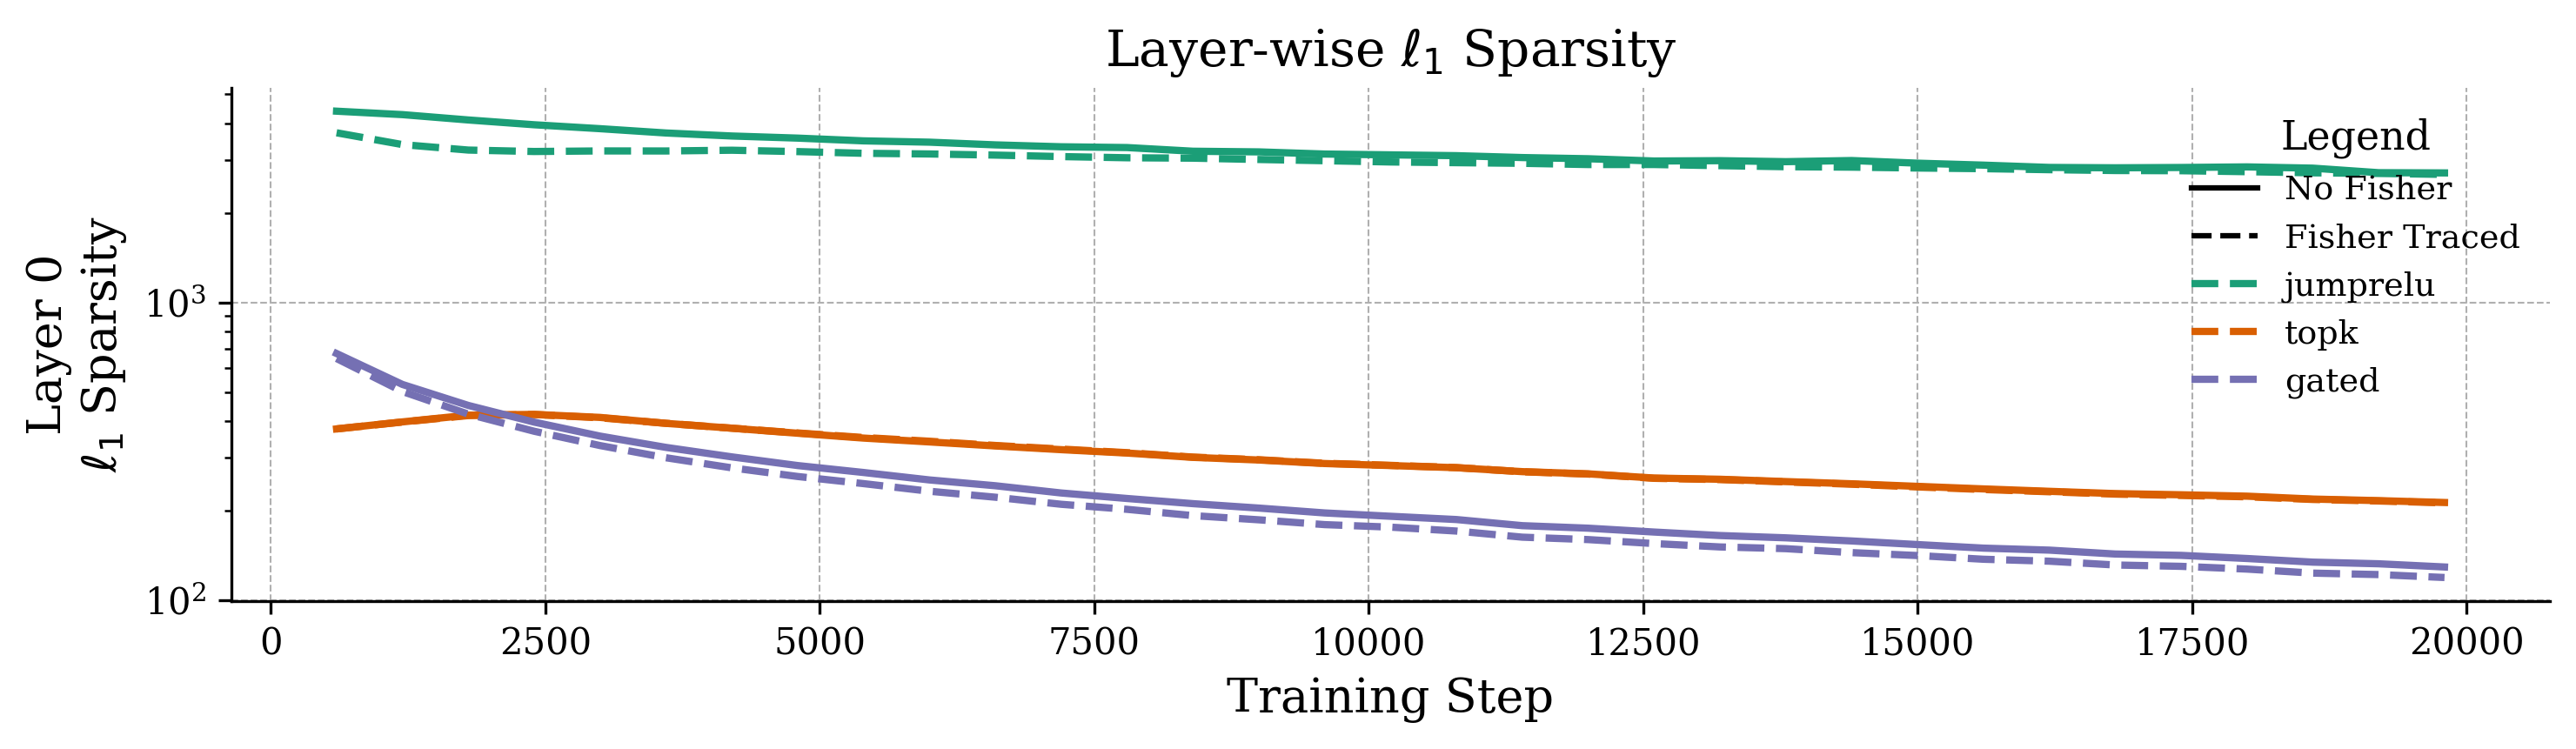

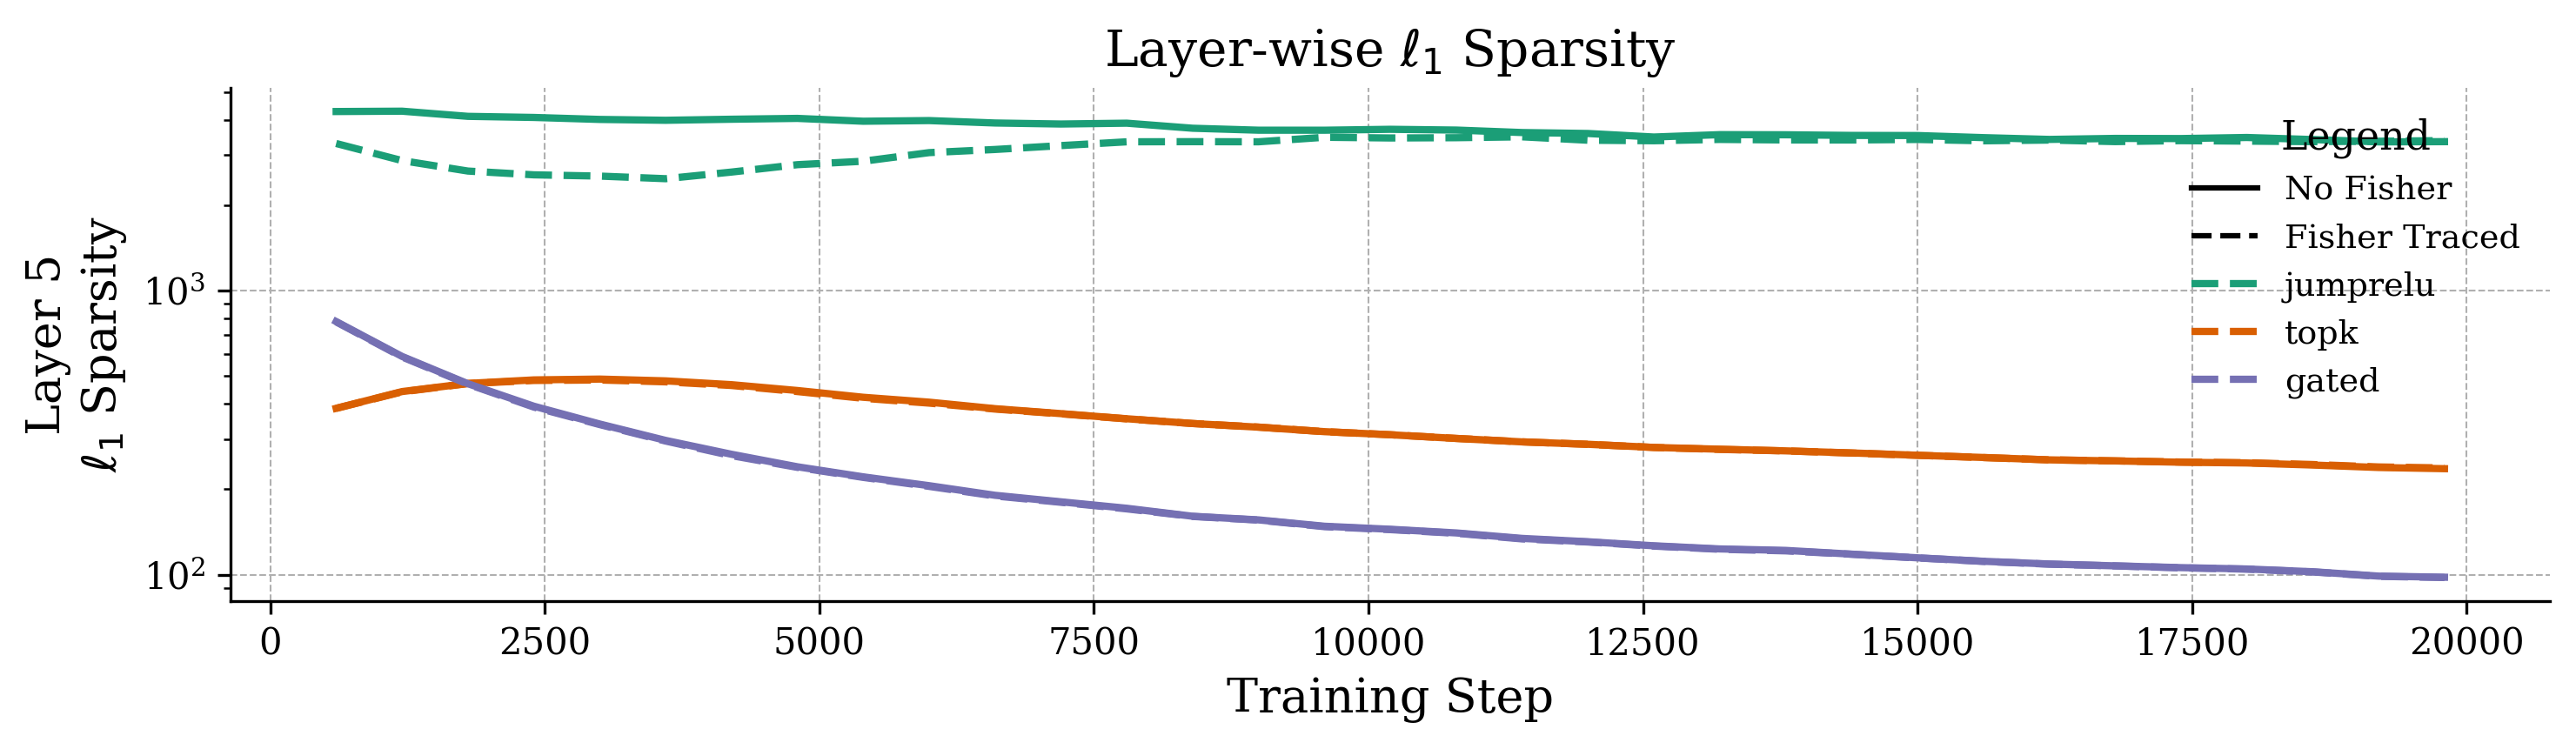

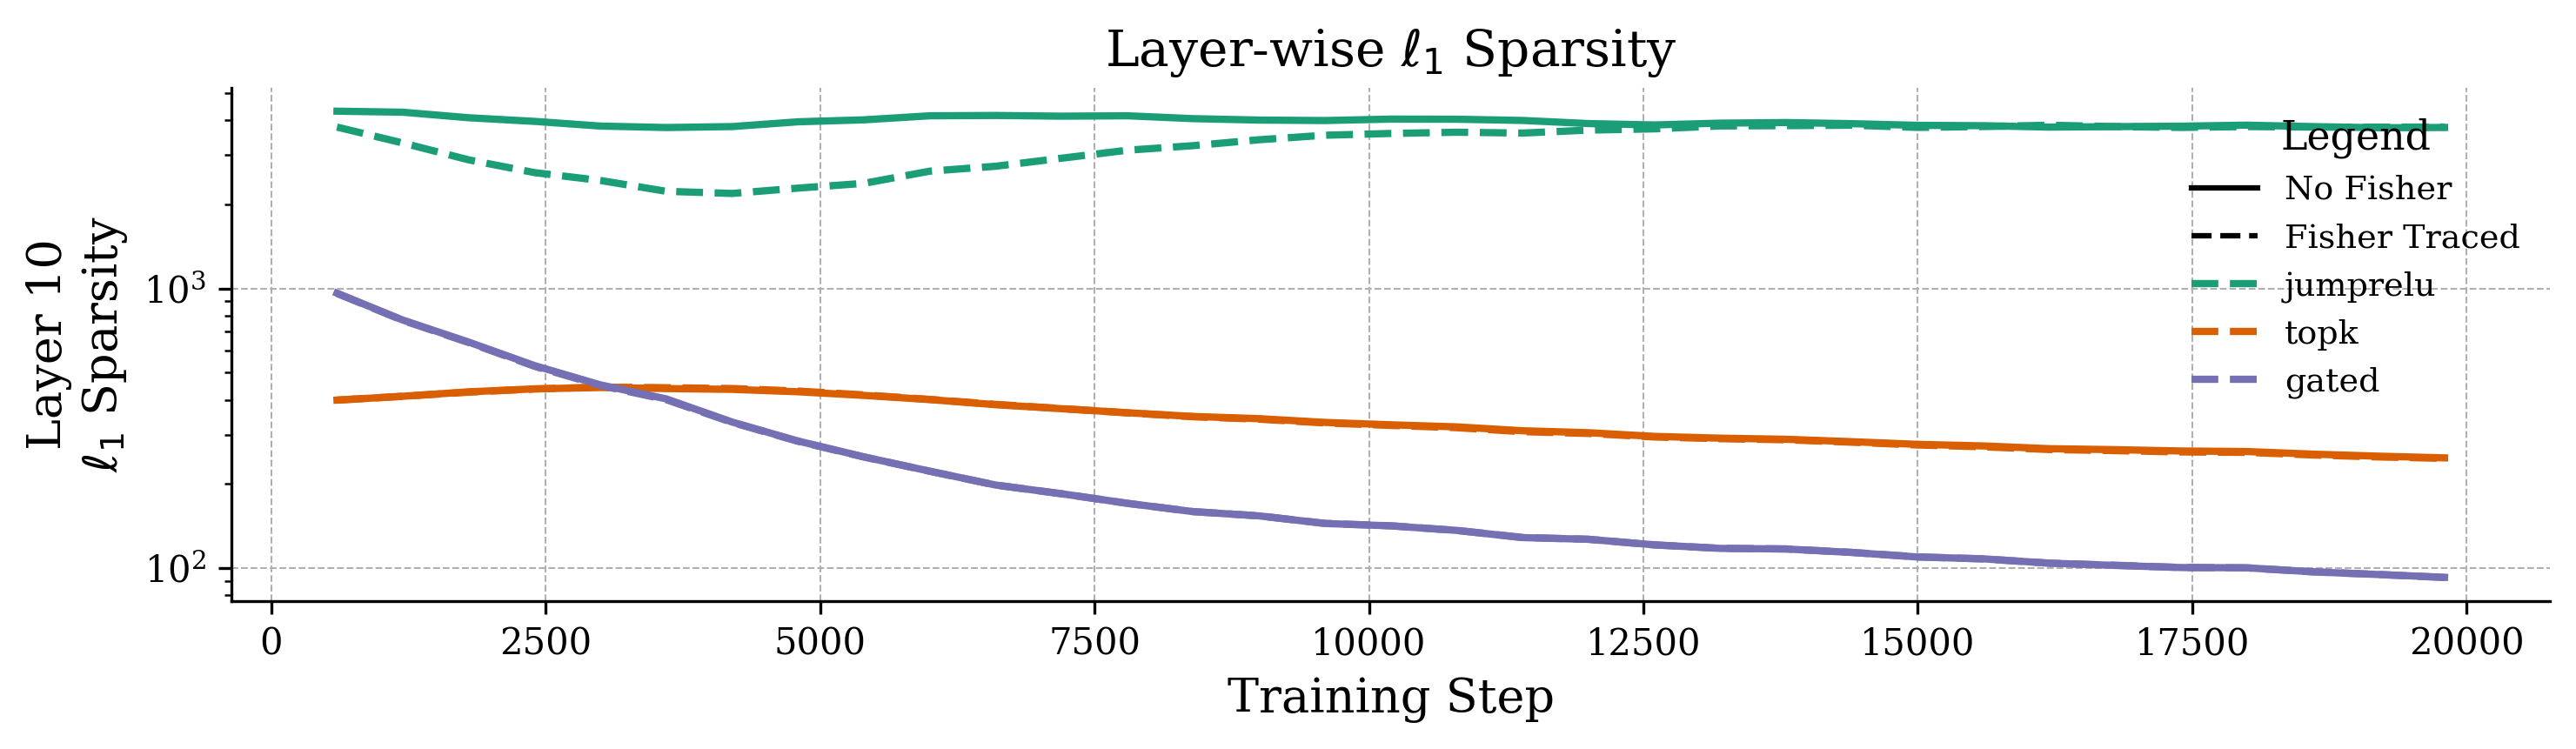

In [71]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_l1_sparsity.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    output_file='Devign_residual_mid/layer0_l1_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_l1_sparsity.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    output_file='Devign_residual_mid/layer5_l1_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_l1_sparsity.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    output_file='Devign_residual_mid/layer10_l1_sparsity_plot.pdf'
)

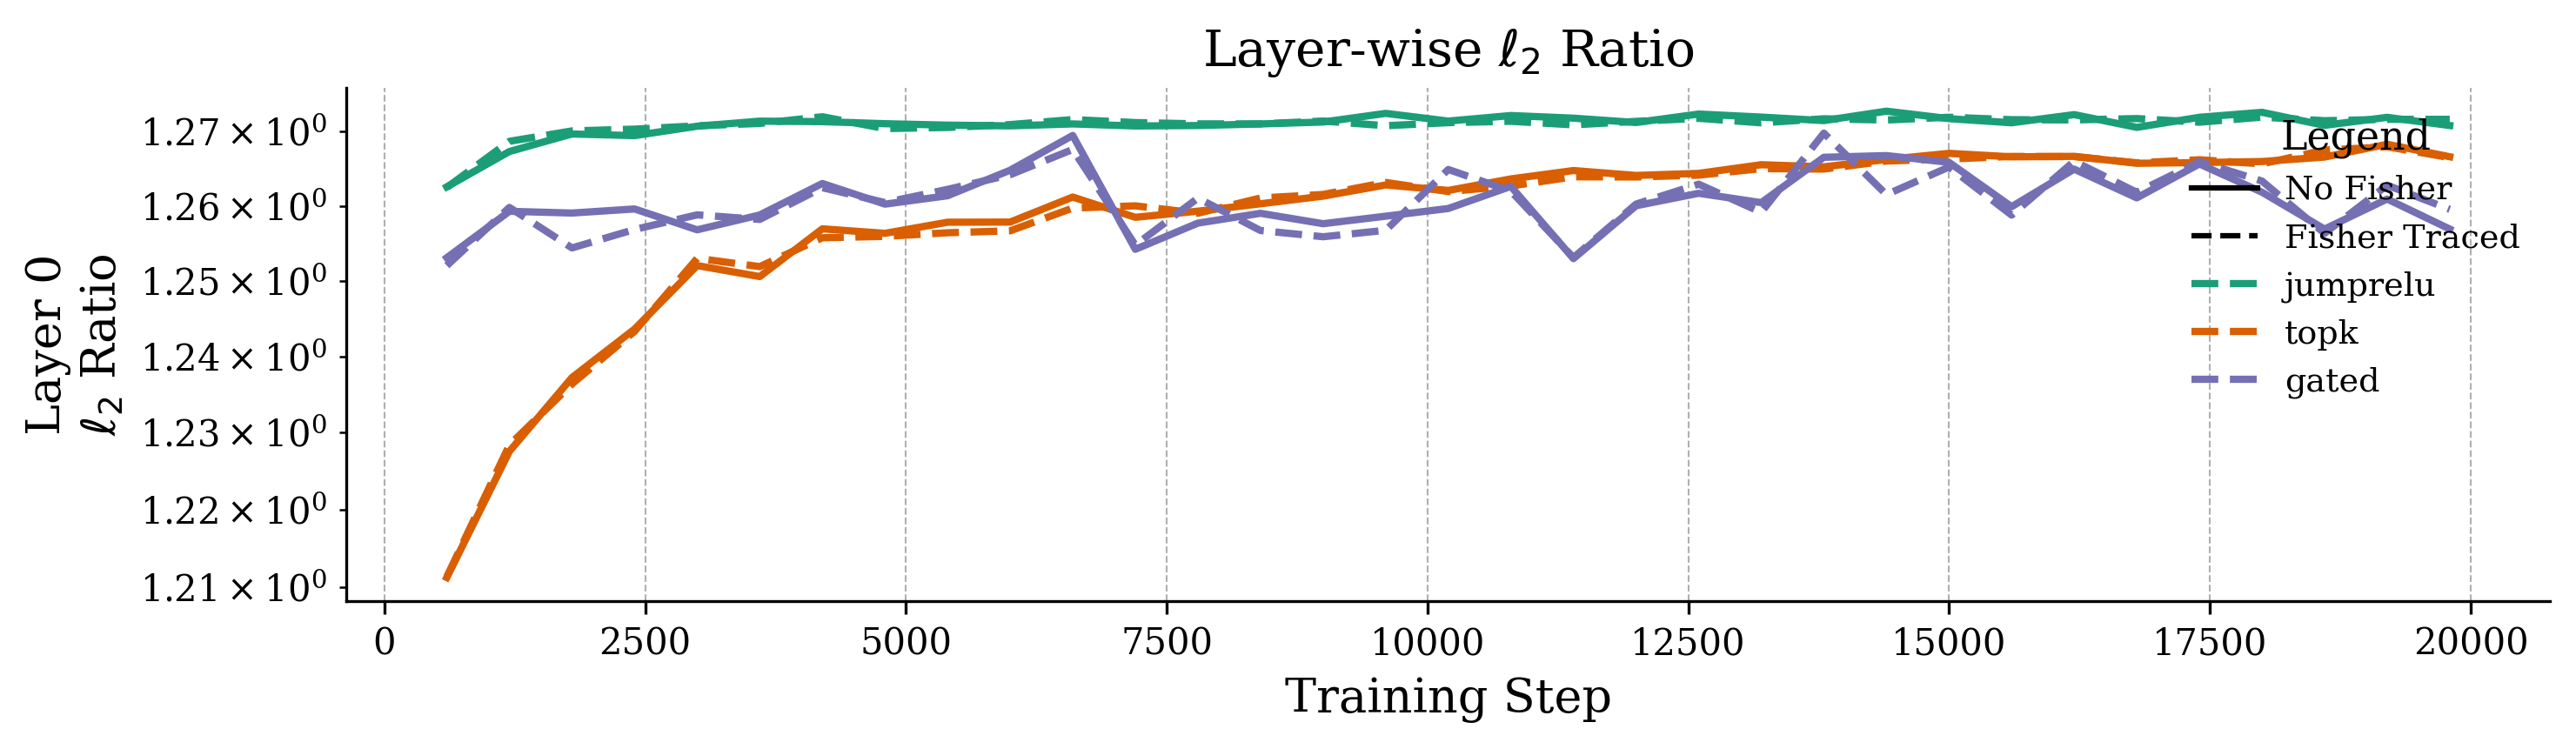

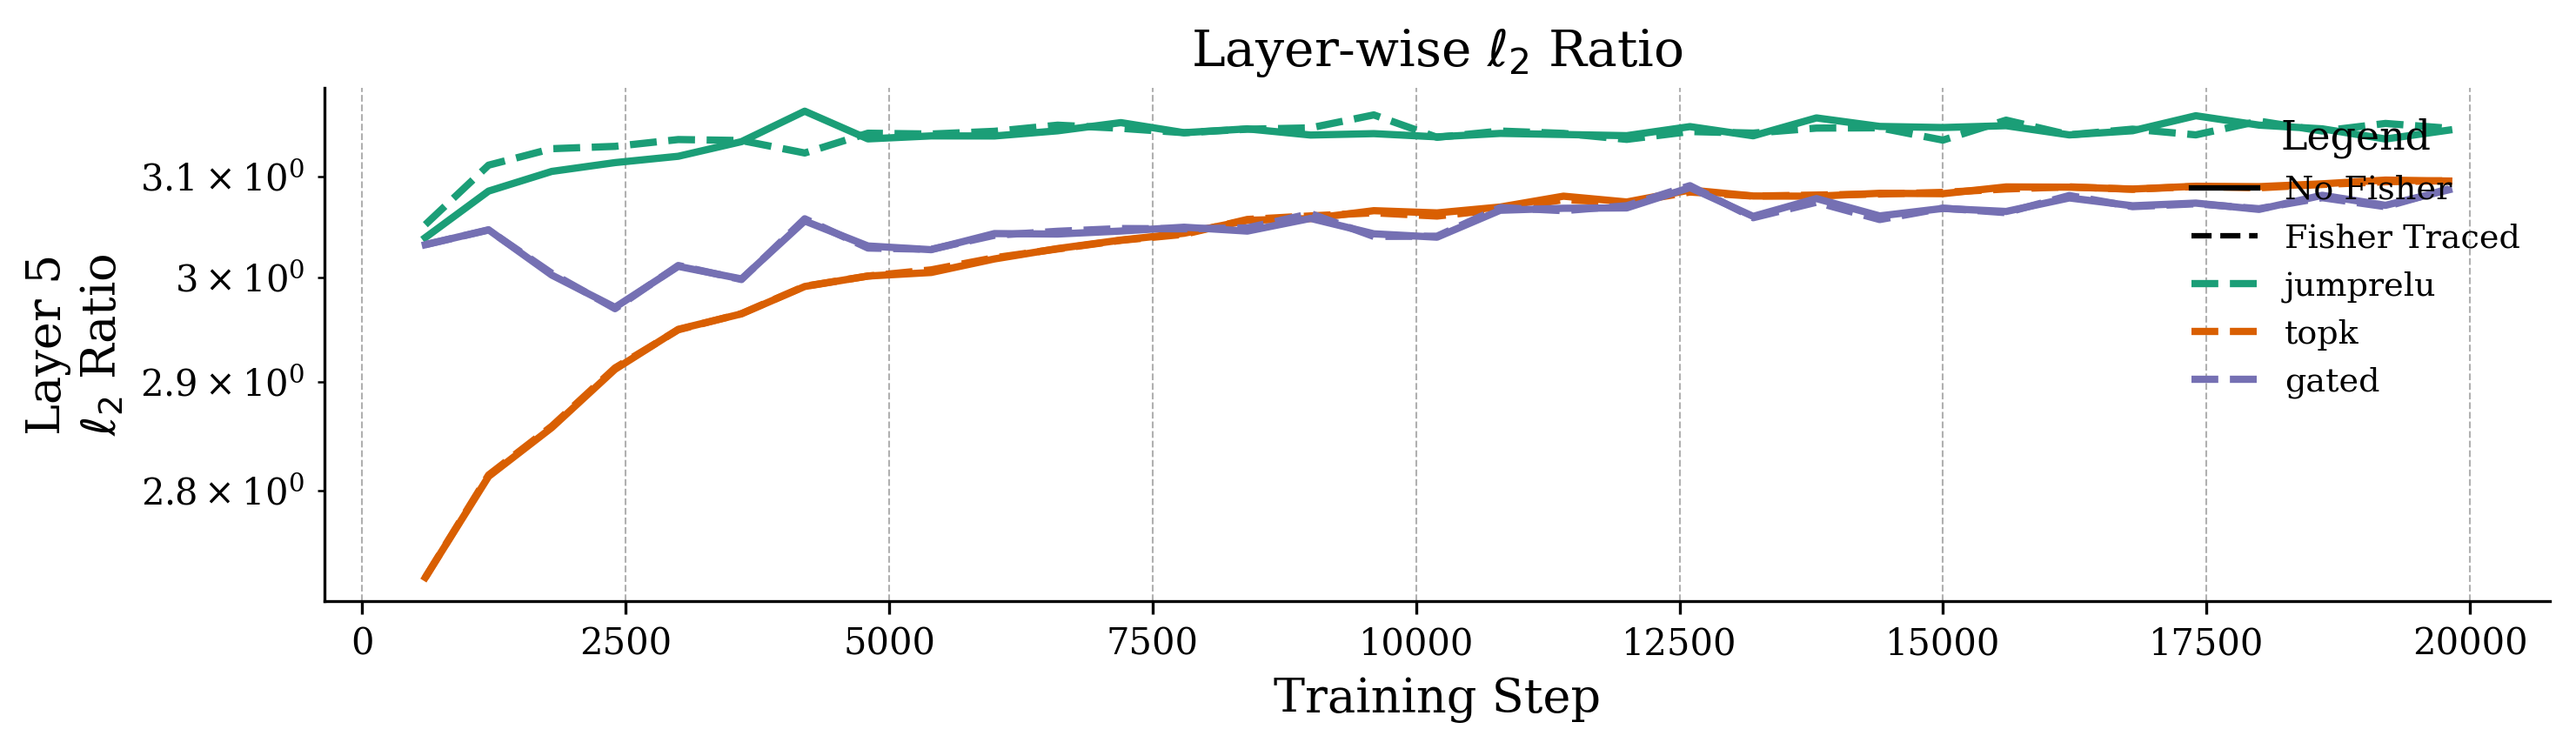

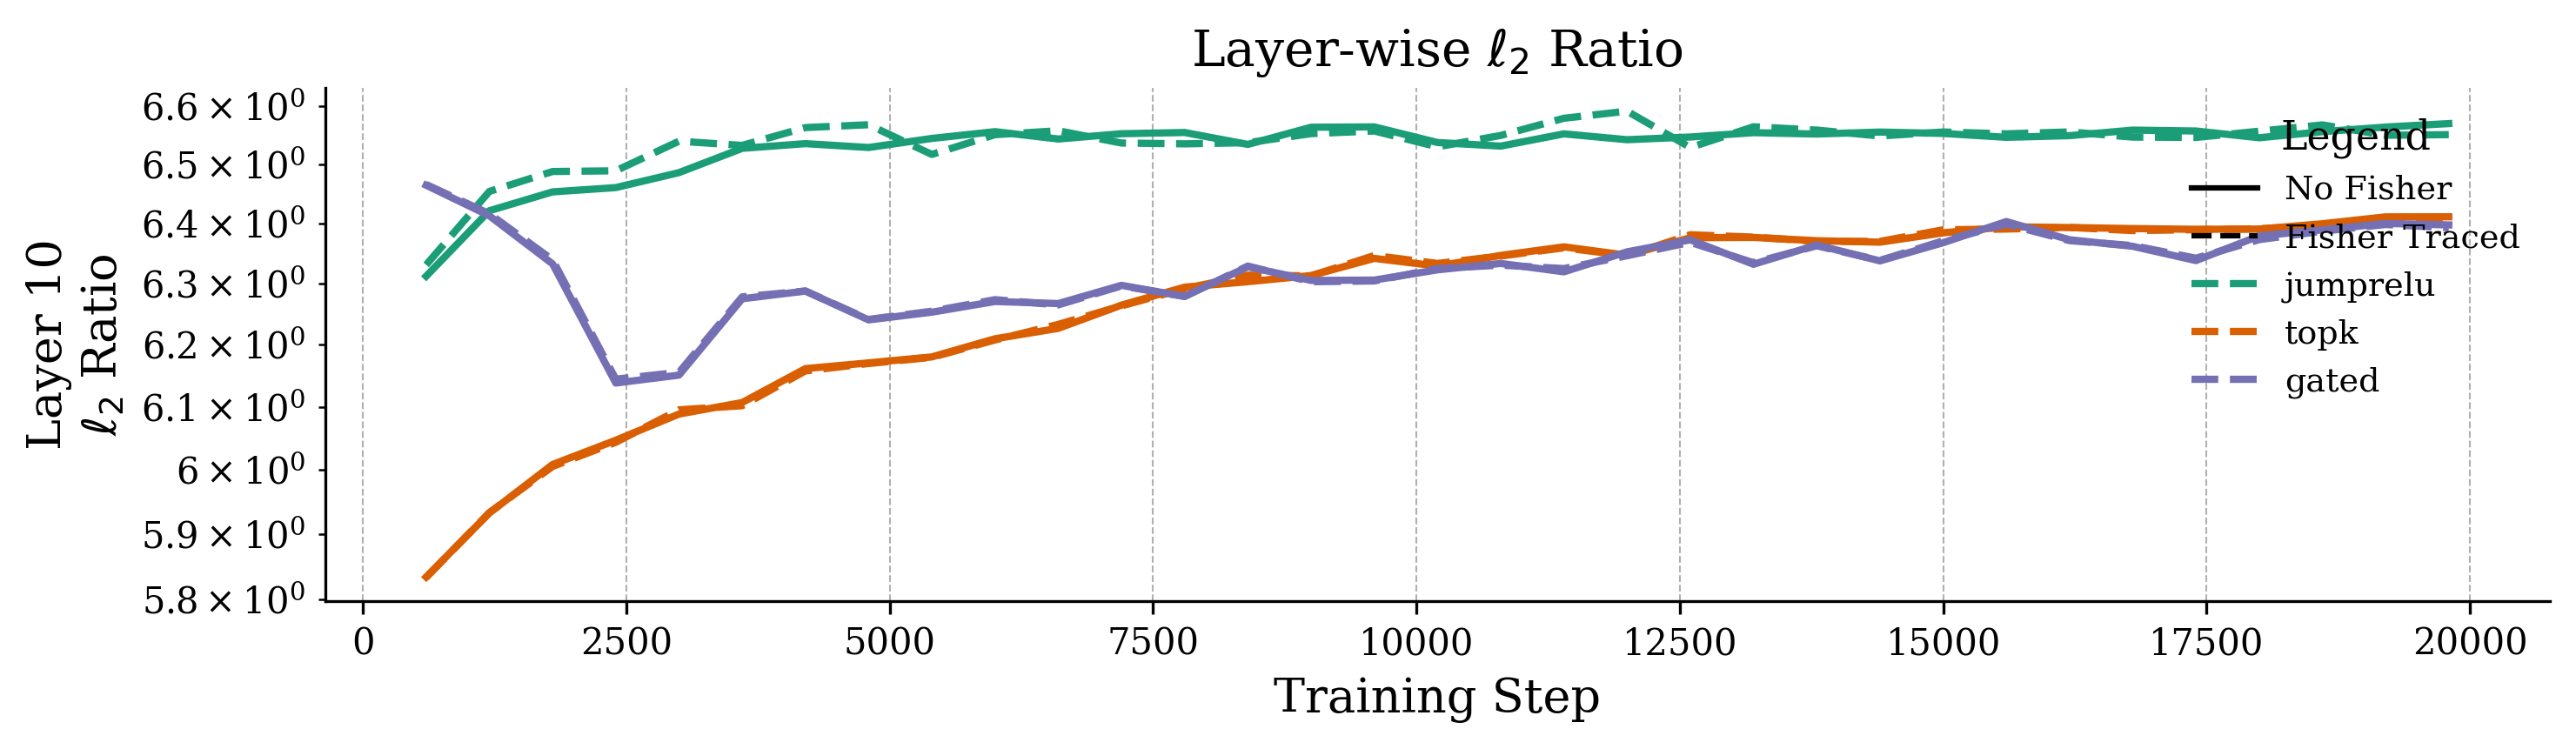

In [72]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_l2_ratio.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    metric='shrinkage.l2_ratio',
    output_file='Devign_residual_mid/layer0_l2_ratio_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_l2_ratio.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    metric='shrinkage.l2_ratio',
    output_file='Devign_residual_mid/layer5_l2_ratio_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_l2_ratio.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    metric='shrinkage.l2_ratio',
    output_file='Devign_residual_mid/layer10_l2_ratio_plot.pdf'
)